In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/Medical_Device_Failure_dataset.csv")

df.head()

,Device_ID,Device_Type,Purchase_Date,Age,Manufacturer,Model,Country,Maintenance_Cost,Downtime,Maintenance_Frequency,Failure_Event_Count,Maintenance_Class,Maintenance_Report
0,MD03449,Defibrillator,2018-04-23,7,CardioSync,Model-100,France,7115.349585,7.933824,3,0,1,Component component upgrade after detecting ov...
1,MD02024,Infusion Pump,2020-12-10,5,MedEquip,Model-650,Italy,7290.780658,7.838711,3,4,2,battery wear caused operational delay; replace...
2,MD04239,MRI Scanner,2023-11-22,2,ImagingTech,Model-650,France,5635.521788,13.911045,1,2,3,data lag caused operational delay; component u...
3,MD00153,Defibrillator,2021-03-03,4,RescueTech,Model-450,UK,5001.360188,29.059510,3,1,3,Routine check completed; battery wear observed...
4,MD03743,Defibrillator,2019-05-16,6,RescueTech,Model-450,Canada,7555.132928,13.942355,4,4,2,Component inspection after detecting voltage s...


In [4]:
df['Maintenance_Class'].value_counts()

,count
Maintenance_Class,
1,1383
2,1383
3,1383


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4149 entries, 0 to 4148
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Device_ID              4149 non-null   object 
 1   Device_Type            4149 non-null   object 
 2   Purchase_Date          4149 non-null   object 
 3   Age                    4149 non-null   int64  
 4   Manufacturer           4149 non-null   object 
 5   Model                  4149 non-null   object 
 6   Country                4149 non-null   object 
 7   Maintenance_Cost       4149 non-null   float64
 8   Downtime               4149 non-null   float64
 9   Maintenance_Frequency  4149 non-null   int64  
 10  Failure_Event_Count    4149 non-null   int64  
 11  Maintenance_Class      4149 non-null   int64  
 12  Maintenance_Report     4149 non-null   object 
dtypes: float64(2), int64(4), object(7)
memory usage: 421.5+ KB


In [8]:
df['Maintenance_Cost'].unique()[:20]

array([ 7115.34958506,  7290.78065849,  5635.52178761,  5001.36018797,
        7555.13292795, 11190.79923653,  4511.50749293, 13615.69324576,
        6311.1958364 , 16619.23669165,  -254.71432017, 21773.54390109,
        8529.63320885, 11482.62078435,  1601.41548081,  3227.75274104,
        4312.0115214 , 14086.92342674,  4293.66255874,  5970.68519938])

In [9]:
df.describe()

,Age,Maintenance_Cost,Downtime,Maintenance_Frequency,Failure_Event_Count,Maintenance_Class
count,4149.000000,4149.000000,4149.000000,4149.00000,4149.000000,4149.000000
mean,6.717763,8643.595669,10.621367,3.01181,1.957821,2.000000
std,3.175610,5930.038551,7.099434,1.42173,1.413328,0.816595
min,1.000000,-5747.932890,0.950068,1.00000,0.000000,1.000000
25%,4.000000,4451.775127,5.066061,2.00000,1.000000,1.000000
50%,7.000000,7213.575604,8.862348,3.00000,2.000000,2.000000
75%,9.000000,12023.912821,14.638223,4.00000,3.000000,3.000000
max,12.000000,34937.222389,34.152648,5.00000,10.000000,3.000000


In [10]:
# check how many devices have a negative maintenance cost
negative_costs = df[df['Maintenance_Cost'] < 0]
print(f"Number of rows with negative Maintenance_Cost: {len(negative_costs)}")
negative_costs.head()

Number of rows with negative Maintenance_Cost: 105


,Device_ID,Device_Type,Purchase_Date,Age,Manufacturer,Model,Country,Maintenance_Cost,Downtime,Maintenance_Frequency,Failure_Event_Count,Maintenance_Class,Maintenance_Report
10,MD04960,MRI Scanner,2014-05-29,11,MedEquip,Model-200,France,-254.714320,10.432459,5,1,3,Component recalibration after detecting softwa...
54,MD05344,PET Scanner,2015-10-14,10,RescueTech,Model-250,France,-3925.998614,14.818425,5,4,2,Routine check completed; overheating observed ...
113,MD01342,Infusion Pump,2022-10-04,3,ImagingTech,Model-350,Japan,-243.762973,16.066491,5,4,2,circuit failure caused operational delay; firm...
145,MD04500,PET Scanner,2019-01-08,6,UltraMed,Model-250,Canada,-724.541672,17.350515,2,2,3,Routine check completed; abnormal sound observ...
147,MD04659,Infusion Pump,2018-03-14,7,CardioSync,Model-400,Japan,-2339.458538,11.080410,5,1,2,System performance degraded due to circuit fai...


In [11]:
# Negative maintenance cost doesn't make real-world sense,
# so we treat it as a sign error and convert it to a positive value
df['Maintenance_Cost'] = df['Maintenance_Cost'].abs()

# double-check: this should now print 0
print(f"Number of rows with negative Maintenance_Cost after fix: {len(df[df['Maintenance_Cost'] < 0])}")

Number of rows with negative Maintenance_Cost after fix: 0


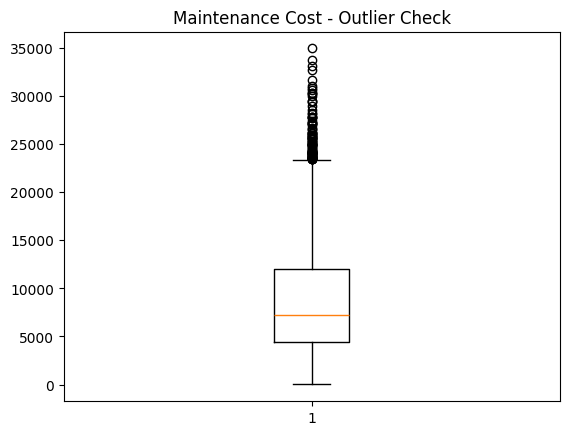

In [12]:
# import plotting library
import matplotlib.pyplot as plt

# check for outliers in Maintenance_Cost using a boxplot
plt.boxplot(df['Maintenance_Cost'])
plt.title('Maintenance Cost - Outlier Check')
plt.show()

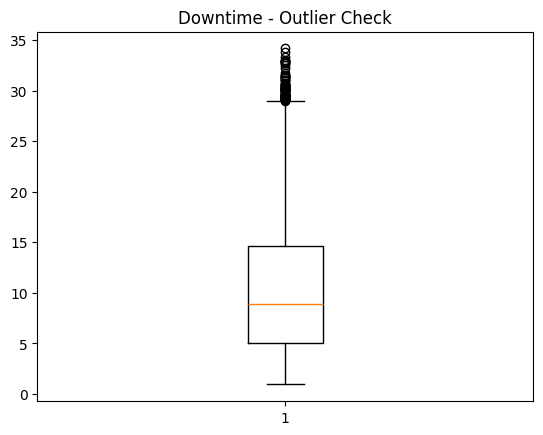

In [13]:
# check for outliers in Downtime using a boxplot
plt.boxplot(df['Downtime'])
plt.title('Downtime - Outlier Check')
plt.show()

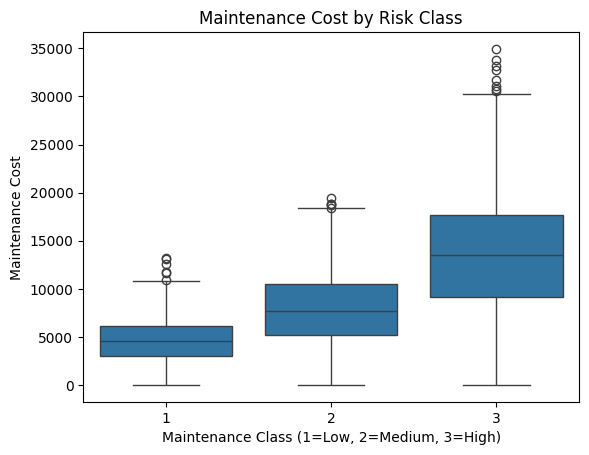

In [14]:
# import seaborn for nicer statistical charts
import seaborn as sns

# compare Maintenance_Cost across the 3 risk classes
# this tells us: do "high risk" (Class 3) devices actually cost more to maintain?
sns.boxplot(x='Maintenance_Class', y='Maintenance_Cost', data=df)
plt.title('Maintenance Cost by Risk Class')
plt.xlabel('Maintenance Class (1=Low, 2=Medium, 3=High)')
plt.ylabel('Maintenance Cost')
plt.show()

In [15]:
# get the exact median Maintenance_Cost for each risk class
df.groupby('Maintenance_Class')['Maintenance_Cost'].median()


,Maintenance_Cost
Maintenance_Class,
1,4558.271922
2,7666.183053
3,13507.201995


In [16]:
df[df['Maintenance_Class'] == 2]['Maintenance_Cost'].median()

7666.183052685559

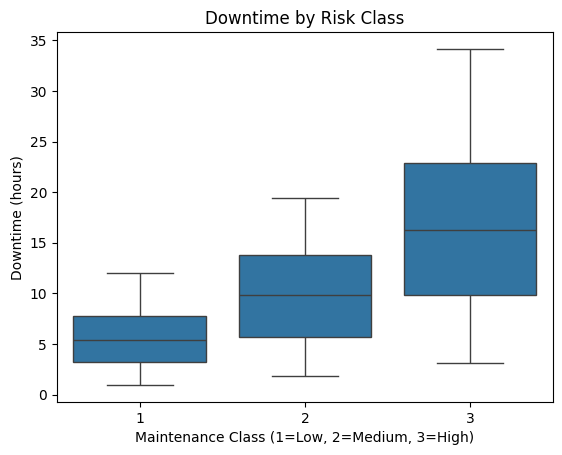

In [17]:
sns.boxplot(x='Maintenance_Class', y='Downtime', data=df)
plt.title('Downtime by Risk Class')
plt.xlabel('Maintenance Class (1=Low, 2=Medium, 3=High)')
plt.ylabel('Downtime (hours)')
plt.show()

In [18]:
df.groupby('Maintenance_Class')['Downtime'].median()

,Downtime
Maintenance_Class,
1,5.377604
2,9.883049
3,16.230508


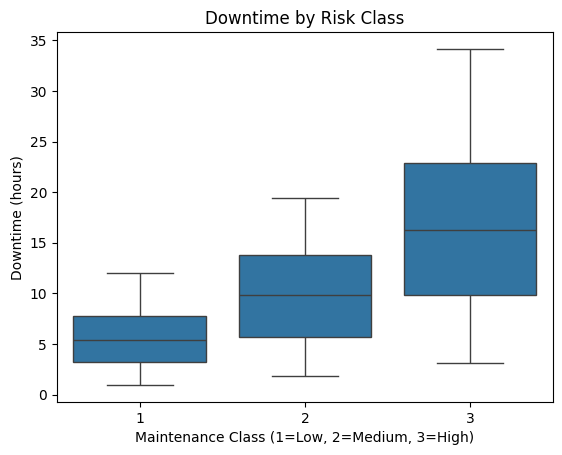

In [20]:
# visual comparison: does downtime differ by risk class?
sns.boxplot(x='Maintenance_Class', y='Downtime', data=df)
plt.title('Downtime by Risk Class')
plt.xlabel('Maintenance Class (1=Low, 2=Medium, 3=High)')
plt.ylabel('Downtime (hours)')
plt.show()

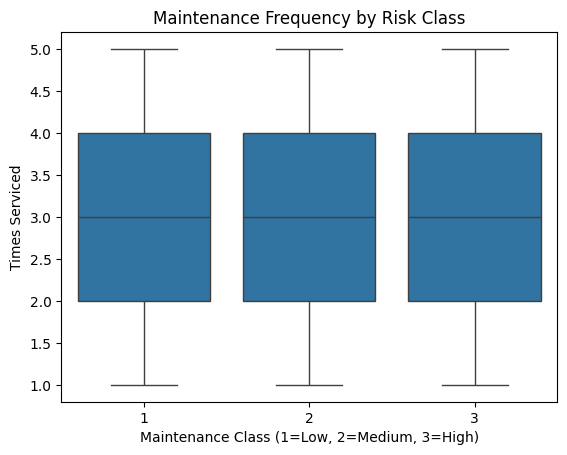

In [21]:
sns.boxplot(x='Maintenance_Class', y='Maintenance_Frequency', data=df)
plt.title('Maintenance Frequency by Risk Class')
plt.xlabel('Maintenance Class (1=Low, 2=Medium, 3=High)')
plt.ylabel('Times Serviced')
plt.show()

In [22]:
# average risk class per device type
device_risk = df.groupby('Device_Type')['Maintenance_Class'].mean().sort_values(ascending=False)
print(device_risk)

Device_Type
PET Scanner      2.025037
X-Ray Machine    2.010974
MRI Scanner      2.008915
Defibrillator    1.987161
Infusion Pump    1.984397
CT Scanner       1.983384
Name: Maintenance_Class, dtype: float64


In [23]:
# select only useful columns for the model
# X = the "clues" we give the model, y = the answer we want it to predict
X = df[['Age', 'Maintenance_Cost', 'Downtime']]
y = df['Maintenance_Class']

X.head()

,Age,Maintenance_Cost,Downtime
0,7,7115.349585,7.933824
1,5,7290.780658,7.838711
2,2,5635.521788,13.911045
3,4,5001.360188,29.059510
4,6,7555.132928,13.942355


In [24]:
from sklearn.model_selection import train_test_split

# split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (3319, 3)
Testing set size: (830, 3)


In [25]:
from sklearn.ensemble import RandomForestClassifier

# create the model
model = RandomForestClassifier(random_state=42)

# train it using our training data (this is where the "learning" happens)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#  the model to predict risk class for the test devices
y_pred = model.predict(X_test)

# compare predictions to the actual correct answers
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nDetailed report:")
print(classification_report(y_test, y_pred))

Accuracy: 71.69%

Detailed report:
              precision    recall  f1-score   support

           1       0.73      0.80      0.76       282
           2       0.63      0.63      0.63       287
           3       0.81      0.72      0.76       261

    accuracy                           0.72       830
   macro avg       0.72      0.72      0.72       830
weighted avg       0.72      0.72      0.72       830



In [27]:
# ============================================
# PROJECT SUMMARY
# ============================================
print("Medical Device Maintenance Risk Prediction")
print("="*50)
print(f"\nDataset: 4,149 medical devices")
print(f"Model used: Random Forest Classifier")
print(f"Features used: Age, Maintenance_Cost, Downtime")
print(f"Target: Maintenance_Class (1=Low, 2=Medium, 3=High risk)")
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")
print(f"\nKey findings:")
print("- Maintenance_Cost and Downtime strongly relate to risk class")
print("- Maintenance_Frequency and Device_Type showed little relationship to risk")
print("- 105 rows had negative Maintenance_Cost values, corrected using absolute value")

Medical Device Maintenance Risk Prediction

Dataset: 4,149 medical devices
Model used: Random Forest Classifier
Features used: Age, Maintenance_Cost, Downtime
Target: Maintenance_Class (1=Low, 2=Medium, 3=High risk)

Model Accuracy: 71.69%

Key findings:
- Maintenance_Cost and Downtime strongly relate to risk class
- Maintenance_Frequency and Device_Type showed little relationship to risk
- 105 rows had negative Maintenance_Cost values, corrected using absolute value
